# Predict cancellation flag
Predict will customer will cancel the order or no

In [2]:
# import data and necessary libraries
import pandas as pd

df = pd.read_csv("../data/processed/food_delivery_final.csv")

df.head()

,order_id,city_tier,customer_age,customer_loyalty_score,order_hour,order_day_of_week,order_month,delivery_distance_km,preparation_time_minutes,delivery_time_minutes,...,festival_or_weekend_flag,delivery_partner_experience_years,delivery_efficiency_score,customer_rating_missing,delivery_partner_rating_missing,delivery_delay_gap,is_peak_hour,cost_per_km,revenue_per_item,is_night_order
0,5a87c6ab-e4a8-44ef-8852-f7a63e3b3943,2,21,4.957522,20,6,6,14.117144,23,76,...,True,9,71.1,0,0,8,True,1.033680,25.000000,False
1,8eab78a5-a5c5-41d7-9a5f-5779ee5f2d3d,1,63,38.744721,0,2,2,9.177354,16,34,...,False,12,100.0,0,0,-6,True,0.478539,14.285714,True
2,1338cc5b-e5cf-419f-a7c9-4a2577608715,1,68,45.170997,9,2,11,34.753921,41,152,...,False,10,34.4,0,0,10,False,0.259148,8.333333,False
3,5277f2fb-b1b3-4f58-9975-12f8f1b71421,2,30,10.573003,6,6,5,26.596184,9,93,...,True,1,45.0,0,0,0,False,0.428897,20.730492,False
4,df159a97-3a78-4b08-a524-ec433c75b670,2,60,58.284620,12,1,9,26.204152,49,141,...,False,6,25.1,0,0,7,True,0.441618,50.000000,False


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, recall_score, precision_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# features
features = [
    'traffic_level_score',
    'weather_severity_score',
    'estimated_delivery_time',
    'delivery_efficiency_score',
    'is_peak_hour',
    'delivery_fee',
    'discount_amount',
    'customer_loyalty_score',
    'restaurant_rating',
]

target = 'cancellation_flag'

X = df[features]
y = df[target]

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# SCALING
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Accuracy: 0.5603
F1 Score: 0.2493
Recall: 0.5573
Precision: 0.1606


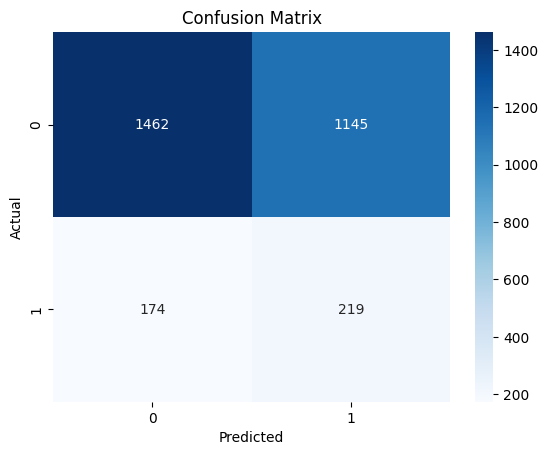

In [4]:
# implementation of logistic regression
lr = LogisticRegression(class_weight='balanced')

# training
lr.fit(X_train_scaled, y_train)

# predictions
y_pred = lr.predict(X_test_scaled)

# evaluation
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")

sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

/home/soufian/Documents/food-delivery-analytics/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Random Forest Accuracy: 0.8690
Random Forest F1 Score: 0.0000
Random Forest Recall: 0.0000
Random Forest Precision: 0.0000


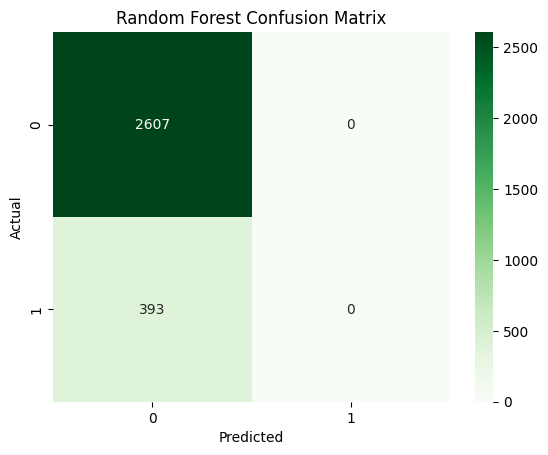

In [5]:
# implementation of random forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(class_weight='balanced', random_state=42)

rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)

# evaluation
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print(f"Random Forest F1 Score: {f1_rf:.4f}")
print(f"Random Forest Recall: {recall_rf:.4f}")
print(f"Random Forest Precision: {precision_rf:.4f}")

sns.heatmap(conf_matrix_rf, annot=True, fmt="d", cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

XGBoost Accuracy: 0.8103
XGBoost F1 Score: 0.1418
XGBoost Recall: 0.1196
XGBoost Precision: 0.1741


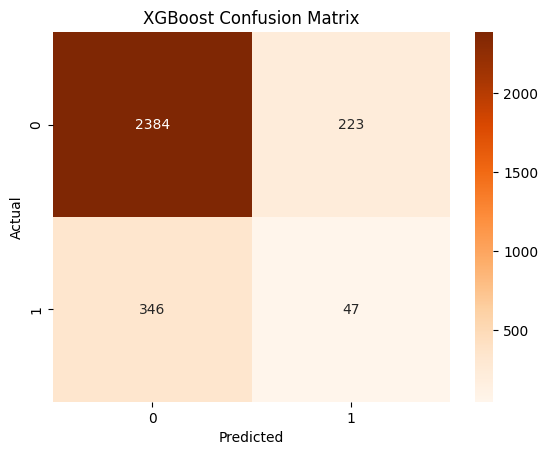

In [6]:
# implementation of XGBoost
from xgboost import XGBClassifier
xgb = XGBClassifier(scale_pos_weight=4, random_state=42)

xgb.fit(X_train_scaled, y_train)

y_pred_xgb = xgb.predict(X_test_scaled)

# evaluation
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)

print(f"XGBoost Accuracy: {accuracy_xgb:.4f}")
print(f"XGBoost F1 Score: {f1_xgb:.4f}")
print(f"XGBoost Recall: {recall_xgb:.4f}")
print(f"XGBoost Precision: {precision_xgb:.4f}")

sns.heatmap(conf_matrix_xgb, annot=True, fmt="d", cmap="Oranges")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.show()

In [7]:
# save the best model (logistic regression in this case) package including model, scaler, features 
import joblib

joblib.dump({
    "model": lr,
    "scaler": scaler,
    "features": features,
    "X_test": X_test,
    "y_test": y_test
}, "../models/classification_model_package.pkl")


['../models/classification_model_package.pkl']